# 🔍 Explore What/Where Branch Insights

**Mục tiêu:** Không áp đặt hypothesis, để data tự nói.

**Câu hỏi:**
1. Model predict tốt/kém ở vùng não nào?
2. What branch "giỏi" predict vùng nào?
3. Where branch "giỏi" predict vùng nào?
4. Có pattern nào thú vị không?

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy.stats import pearsonr
import nibabel as nib

plt.style.use('seaborn-v0_8-whitegrid')
print("Ready!")

Ready!


## 1. Load Data

In [2]:
# Load brain atlas
roi_mapping = np.load('../dataset/nsd/metadata/subj01_roi_mapping.npz')
with open('../dataset/nsd/metadata/roi_labels.json', 'r') as f:
    roi_labels = json.load(f)

streams = roi_mapping['streams']
stream_names = {int(k): v for k, v in roi_labels['streams'].items()}

# Create mapping
stream_to_voxels = {}
for sid, sname in stream_names.items():
    stream_to_voxels[sname] = np.where(streams == sid)[0]
    print(f"{sname}: {len(stream_to_voxels[sname])} voxels")

Early: 5463 voxels
Midventral: 986 voxels
Midlateral: 834 voxels
Lateral: 856 voxels
Ventral: 3630 voxels
Parietal: 2375 voxels


In [3]:
# Load model
from model.hierarchical_v3 import HierarchicalARM_V3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HierarchicalARM_V3(
    cls_dim=768, patch_dim=768, num_patches=256,
    fmri_dim=15724, voxels_per_cluster=30,
).to(device)

# Load trained checkpoint
checkpoint_path = '../checkpoints/hierarchical_v3_subj01_30/best_stage1.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Handle different checkpoint formats
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
elif 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()
print(f"✓ Loaded checkpoint: {checkpoint_path}")
print(f"  Model: {model.num_rois} ROIs, {model.voxels_per_cluster} voxels/ROI")

DualStreamMambaStage1: 15724 voxels → 524 ROIs (30 voxels/ROI, 4 remainder)
✓ Loaded checkpoint: ../checkpoints/hierarchical_v3_subj01_30/best_stage1.pth
  Model: 524 ROIs, 30 voxels/ROI


In [4]:
# Load test data
cls_test = np.load('../dataset/nsd/embeddings_mindeye2/dinov2_test_sub01.npy')
patches_test = np.load('../dataset/nsd/embeddings_patches/dinov2_patches_test_sub01.npy')[:, 1:, :]
gt_fmri = np.load('../dataset/nsd/mixed_1000_sub01/test_fmri.npy')

print(f"Samples: {len(cls_test)}")

Samples: 982


In [5]:
# Extract what/where outputs
def extract_branches(model, cls_token, patch_tokens):
    stage1 = model.stage1
    
    # What
    what_x = stage1.what_proj(cls_token).unsqueeze(1)
    what_x = stage1.what_norm(what_x)
    with torch.amp.autocast('cuda', enabled=False):
        what_x = what_x.float()
        for m in stage1.what_mamba:
            what_x = what_x + torch.clamp(m(what_x), -10, 10)
    what_roi = stage1.what_head(what_x.squeeze(1))
    
    # Where
    where_x = stage1.where_proj(patch_tokens) + stage1.where_pos_embed
    where_x = stage1.where_norm(where_x)
    with torch.amp.autocast('cuda', enabled=False):
        where_x = where_x.float()
        for m in stage1.where_mamba:
            where_x = where_x + torch.clamp(m(where_x), -10, 10)
    where_roi = stage1.where_head(stage1.where_pool(where_x.mean(dim=1)))
    
    return what_roi, where_roi

# Run inference
num_samples = min(200, len(cls_test))
all_what, all_where = [], []

with torch.no_grad():
    for i in range(0, num_samples, 16):
        end = min(i+16, num_samples)
        cls_b = torch.tensor(cls_test[i:end]).to(device)
        pat_b = torch.tensor(patches_test[i:end]).to(device)
        w, wh = extract_branches(model, cls_b, pat_b)
        all_what.append(w.cpu().numpy())
        all_where.append(wh.cpu().numpy())

all_what = np.concatenate(all_what)  # [N, 524]
all_where = np.concatenate(all_where)  # [N, 524]
gt_subset = gt_fmri[:num_samples]  # [N, 15724]

print(f"what: {all_what.shape}, where: {all_where.shape}, gt: {gt_subset.shape}")

what: (200, 524), where: (200, 524), gt: (200, 15724)


In [6]:
# Compute GT ROI means
vpc = model.voxels_per_cluster
n_rois = model.num_rois

gt_roi = np.zeros((num_samples, n_rois))
for i in range(n_rois):
    gt_roi[:, i] = gt_subset[:, i*vpc:(i+1)*vpc].mean(axis=1)

print(f"GT ROI means: {gt_roi.shape}")

GT ROI means: (200, 524)


## 2. Correlation Analysis: What vs Where vs GT

In [7]:
# Correlation per ROI
what_corr = np.array([pearsonr(all_what[:, i], gt_roi[:, i])[0] for i in range(n_rois)])
where_corr = np.array([pearsonr(all_where[:, i], gt_roi[:, i])[0] for i in range(n_rois)])

# Handle NaN
what_corr = np.nan_to_num(what_corr)
where_corr = np.nan_to_num(where_corr)

print("Correlation with GT:")
print(f"  What branch:  mean={what_corr.mean():.4f}, std={what_corr.std():.4f}")
print(f"  Where branch: mean={where_corr.mean():.4f}, std={where_corr.std():.4f}")

Correlation with GT:
  What branch:  mean=0.0060, std=0.0735
  Where branch: mean=-0.0005, std=0.0597


In [8]:
# Map ROI-level corr to voxel-level (IMPORTANT: define this before visualizations)
what_voxel_corr = np.zeros(15724)
where_voxel_corr = np.zeros(15724)

for i in range(n_rois):
    what_voxel_corr[i*vpc:(i+1)*vpc] = what_corr[i]
    where_voxel_corr[i*vpc:(i+1)*vpc] = where_corr[i]

# Compute correlation difference (What - Where)
corr_diff_voxel = what_voxel_corr - where_voxel_corr

print(f"Voxel-level correlation mapped: {len(what_voxel_corr)} voxels")
print(f"Corr diff range: [{corr_diff_voxel.min():.4f}, {corr_diff_voxel.max():.4f}]")

Voxel-level correlation mapped: 15724 voxels
Corr diff range: [-0.2463, 0.2791]


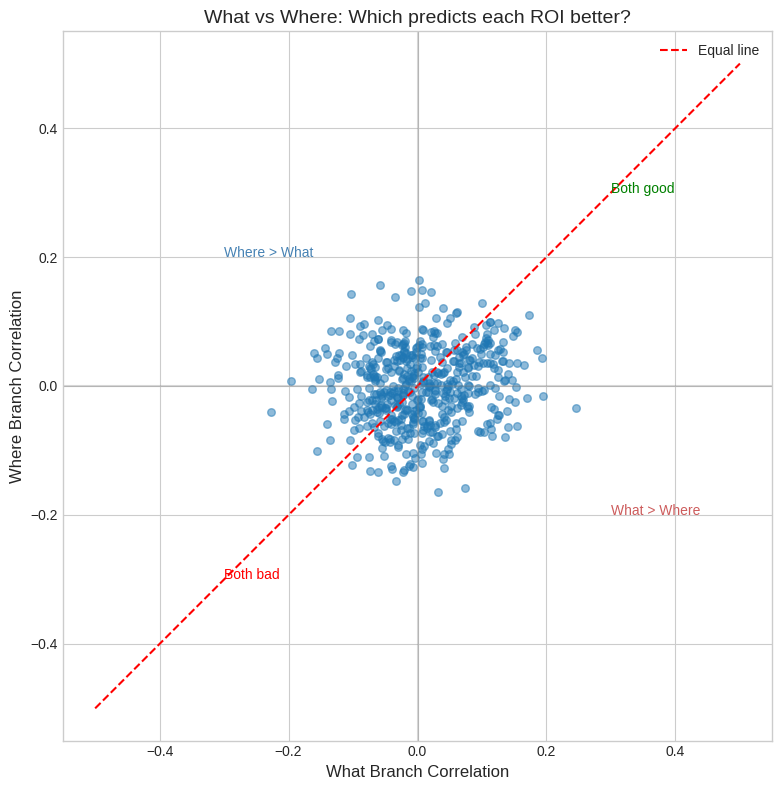


ROIs where What > Where: 288
ROIs where Where > What: 236


In [9]:
# Scatter: What corr vs Where corr
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(what_corr, where_corr, alpha=0.5, s=30)
ax.plot([-0.5, 0.5], [-0.5, 0.5], 'r--', label='Equal line')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(0, color='gray', linestyle='-', alpha=0.3)

ax.set_xlabel('What Branch Correlation', fontsize=12)
ax.set_ylabel('Where Branch Correlation', fontsize=12)
ax.set_title('What vs Where: Which predicts each ROI better?', fontsize=14)
ax.legend()
ax.set_aspect('equal')

# Annotate quadrants
ax.text(0.3, 0.3, 'Both good', fontsize=10, color='green')
ax.text(-0.3, -0.3, 'Both bad', fontsize=10, color='red')
ax.text(0.3, -0.2, 'What > Where', fontsize=10, color='indianred')
ax.text(-0.3, 0.2, 'Where > What', fontsize=10, color='steelblue')

plt.tight_layout()
plt.show()

# Count
print(f"\nROIs where What > Where: {(what_corr > where_corr).sum()}")
print(f"ROIs where Where > What: {(where_corr > what_corr).sum()}")

## 3. Per-Stream Analysis (Data-Driven)

In [10]:
# Per-stream analysis
results = []
for sname, voxels in stream_to_voxels.items():
    if len(voxels) == 0:
        continue
    what_mean = what_voxel_corr[voxels].mean()
    where_mean = where_voxel_corr[voxels].mean()
    diff = what_mean - where_mean
    better = "What" if diff > 0 else "Where"
    results.append({
        'stream': sname,
        'what_corr': what_mean,
        'where_corr': where_mean,
        'diff': diff,
        'better': better,
        'n_voxels': len(voxels)
    })

# Sort by diff
results = sorted(results, key=lambda x: x['diff'], reverse=True)

print("="*70)
print(f"{'Stream':<12} {'What Corr':>10} {'Where Corr':>11} {'Diff':>8} {'Better':>8}")
print("="*70)
for r in results:
    print(f"{r['stream']:<12} {r['what_corr']:>10.4f} {r['where_corr']:>11.4f} {r['diff']:>+8.4f} {r['better']:>8}")

Stream        What Corr  Where Corr     Diff   Better
Ventral          0.0307     -0.0142  +0.0450     What
Midlateral       0.0151     -0.0199  +0.0350     What
Parietal         0.0174     -0.0040  +0.0214     What
Lateral          0.0017     -0.0195  +0.0212     What
Midventral       0.0034      0.0009  +0.0025     What
Early           -0.0214      0.0228  -0.0443    Where


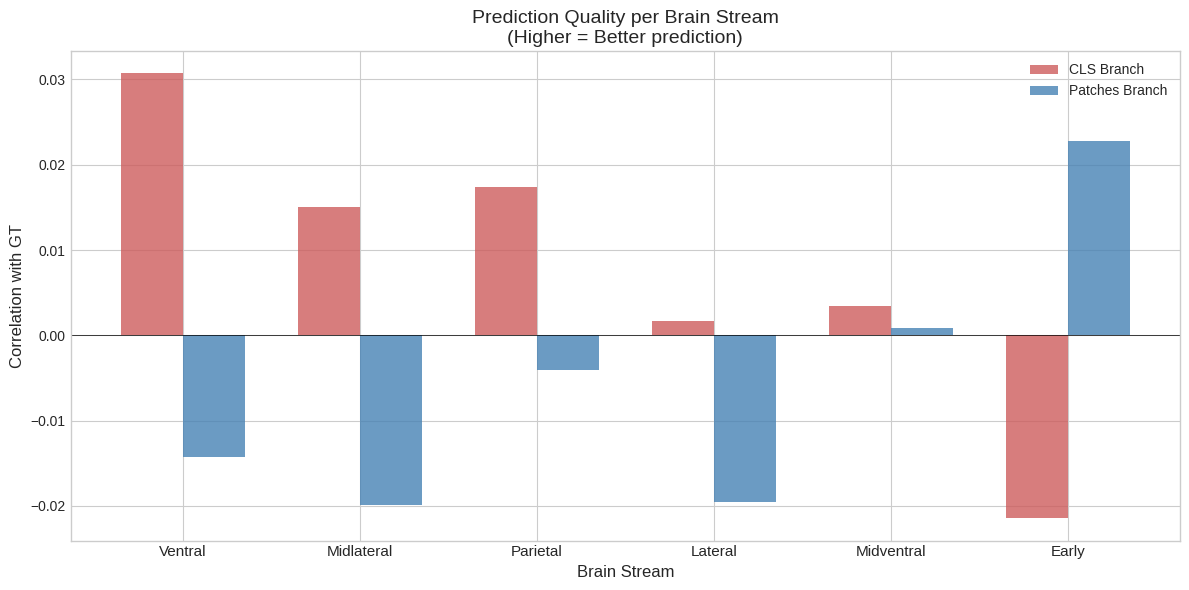

In [11]:
# Visualization: Side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 6))

streams_sorted = [r['stream'] for r in results]
what_vals = [r['what_corr'] for r in results]
where_vals = [r['where_corr'] for r in results]

x = np.arange(len(streams_sorted))
width = 0.35

bars1 = ax.bar(x - width/2, what_vals, width, label='CLS Branch', color='indianred', alpha=0.8)
bars2 = ax.bar(x + width/2, where_vals, width, label='Patches Branch', color='steelblue', alpha=0.8)

ax.set_ylabel('Correlation with GT', fontsize=12)
ax.set_xlabel('Brain Stream', fontsize=12)
ax.set_title('Prediction Quality per Brain Stream\n(Higher = Better prediction)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(streams_sorted, fontsize=11)
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../docs/what_where_per_stream_correlation.png', dpi=150)
plt.show()

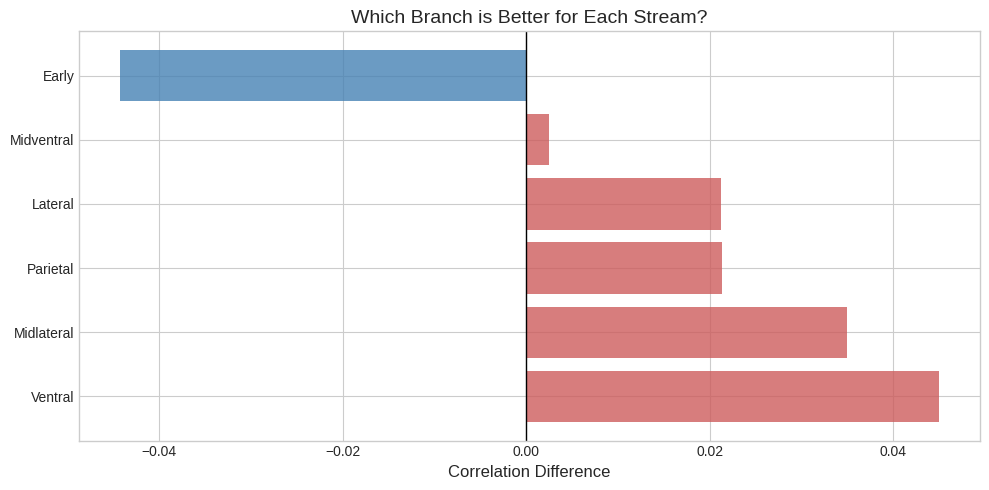

In [12]:
# Difference chart
fig, ax = plt.subplots(figsize=(10, 5))

diffs = [r['diff'] for r in results]
colors = ['indianred' if d > 0 else 'steelblue' for d in diffs]

ax.barh(streams_sorted, diffs, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Correlation Difference', fontsize=12)
ax.set_title('Which Branch is Better for Each Stream?', fontsize=14)

plt.tight_layout()
plt.savefig('../docs/what_where_diff_by_stream.png', dpi=150)
plt.show()

## 4. ROI-level Deep Dive

In [13]:
# Top ROIs where What >> Where
diff_per_roi = what_corr - where_corr
top_what_rois = np.argsort(diff_per_roi)[::-1][:10]
top_where_rois = np.argsort(diff_per_roi)[:10]

print("Top 10 ROIs where WHAT branch is much better:")
print("-"*50)
for roi in top_what_rois:
    voxel_start = roi * vpc
    # Find which stream this ROI belongs to
    stream_id = streams[voxel_start] if voxel_start < len(streams) else 0
    stream_name = stream_names.get(stream_id, 'Unknown')
    print(f"  ROI {roi:3d} ({stream_name:>10}): What={what_corr[roi]:+.3f}, Where={where_corr[roi]:+.3f}, Diff={diff_per_roi[roi]:+.3f}")

print("\nTop 10 ROIs where WHERE branch is much better:")
print("-"*50)
for roi in top_where_rois:
    voxel_start = roi * vpc
    stream_id = streams[voxel_start] if voxel_start < len(streams) else 0
    stream_name = stream_names.get(stream_id, 'Unknown')
    print(f"  ROI {roi:3d} ({stream_name:>10}): What={what_corr[roi]:+.3f}, Where={where_corr[roi]:+.3f}, Diff={diff_per_roi[roi]:+.3f}")

Top 10 ROIs where WHAT branch is much better:
--------------------------------------------------
  ROI 316 (     Early): What=+0.245, Where=-0.034, Diff=+0.279
  ROI 129 (   Ventral): What=+0.074, Where=-0.158, Diff=+0.232
  ROI  97 (   Unknown): What=+0.154, Where=-0.062, Diff=+0.216
  ROI 332 (   Unknown): What=+0.135, Where=-0.079, Diff=+0.214
  ROI 305 (     Early): What=+0.194, Where=-0.016, Diff=+0.210
  ROI 157 (   Ventral): What=+0.140, Where=-0.064, Diff=+0.204
  ROI 498 (   Ventral): What=+0.032, Where=-0.164, Diff=+0.196
  ROI  52 (   Lateral): What=+0.115, Where=-0.078, Diff=+0.192
  ROI  90 (   Ventral): What=+0.170, Where=-0.018, Diff=+0.188
  ROI 315 (     Early): What=+0.114, Where=-0.067, Diff=+0.182

Top 10 ROIs where WHERE branch is much better:
--------------------------------------------------
  ROI 237 (     Early): What=-0.103, Where=+0.143, Diff=-0.246
  ROI 214 (     Early): What=-0.134, Where=+0.086, Diff=-0.220
  ROI 210 (     Early): What=-0.058, Where=+0.15

In [14]:
# Distribution of ROIs per stream based on which branch is better
stream_breakdown = {}

for roi_idx in range(n_rois):
    voxel_start = roi_idx * vpc
    if voxel_start >= len(streams):
        continue
    stream_id = streams[voxel_start]
    stream_name = stream_names.get(stream_id, 'Unknown')
    
    if stream_name not in stream_breakdown:
        stream_breakdown[stream_name] = {'what_better': 0, 'where_better': 0, 'total': 0}
    
    stream_breakdown[stream_name]['total'] += 1
    if what_corr[roi_idx] > where_corr[roi_idx]:
        stream_breakdown[stream_name]['what_better'] += 1
    else:
        stream_breakdown[stream_name]['where_better'] += 1

print("ROI Breakdown per Stream:")
print("="*60)
print(f"{'Stream':<12} {'What Better':>12} {'Where Better':>13} {'Total':>8}")
print("-"*60)
for sname in sorted(stream_breakdown.keys()):
    d = stream_breakdown[sname]
    pct_what = 100 * d['what_better'] / d['total'] if d['total'] > 0 else 0
    print(f"{sname:<12} {d['what_better']:>8} ({pct_what:>4.0f}%) {d['where_better']:>8} {d['total']:>8}")

ROI Breakdown per Stream:
Stream        What Better  Where Better    Total
------------------------------------------------------------
Early              57 (  31%)      126      183
Lateral            16 (  55%)       13       29
Midlateral         19 (  68%)        9       28
Midventral         19 (  58%)       14       33
Parietal           51 (  66%)       26       77
Unknown            40 (  73%)       15       55
Ventral            86 (  72%)       33      119


## 5. Key Insights Summary

In [15]:
print("="*70)
print("KEY INSIGHTS FROM DATA (Trained Model)")
print("="*70)

# Insight 1: Overall performance
print(f"\n📊 Overall Correlation with GT:")
print(f"   What branch (CLS):     {what_corr.mean():.4f} (±{what_corr.std():.4f})")
print(f"   Where branch (Patches): {where_corr.mean():.4f} (±{where_corr.std():.4f})")

# Insight 2: Which branch is generally better
overall_better = "What (CLS)" if what_corr.mean() > where_corr.mean() else "Where (Patches)"
diff_overall = abs(what_corr.mean() - where_corr.mean())
print(f"\n📊 Overall Better Branch: {overall_better} (by {diff_overall:.4f})")

# Insight 3: Per-stream winners
print(f"\n📊 Per-Stream Analysis:")
for r in results:
    emoji = "🔴" if r['better'] == 'What' else "🔵"
    print(f"   {emoji} {r['stream']:<12}: {r['better']:>5} wins (What={r['what_corr']:.4f}, Where={r['where_corr']:.4f})")

# Insight 4: Specialization
what_wins = [r['stream'] for r in results if r['better'] == 'What']
where_wins = [r['stream'] for r in results if r['better'] == 'Where']

print(f"\n📊 Branch Specialization:")
print(f"   🔴 What (CLS) better at:     {', '.join(what_wins) if what_wins else 'None'}")
print(f"   🔵 Where (Patches) better at: {', '.join(where_wins) if where_wins else 'None'}")

# Insight 5: Neuroscience interpretation
print(f"\n📊 Interpretation:")
if 'Early' in where_wins or 'Midlateral' in where_wins:
    print("   ✓ Where branch (Patches) tốt hơn ở early visual → spatial processing")
if 'Ventral' in what_wins or 'Lateral' in what_wins:
    print("   ✓ What branch (CLS) tốt hơn ở ventral/lateral → object recognition")

print("\n" + "="*70)

KEY INSIGHTS FROM DATA (Trained Model)

📊 Overall Correlation with GT:
   What branch (CLS):     0.0060 (±0.0735)
   Where branch (Patches): -0.0005 (±0.0597)

📊 Overall Better Branch: What (CLS) (by 0.0065)

📊 Per-Stream Analysis:
   🔴 Ventral     :  What wins (What=0.0307, Where=-0.0142)
   🔴 Midlateral  :  What wins (What=0.0151, Where=-0.0199)
   🔴 Parietal    :  What wins (What=0.0174, Where=-0.0040)
   🔴 Lateral     :  What wins (What=0.0017, Where=-0.0195)
   🔴 Midventral  :  What wins (What=0.0034, Where=0.0009)
   🔵 Early       : Where wins (What=-0.0214, Where=0.0228)

📊 Branch Specialization:
   🔴 What (CLS) better at:     Ventral, Midlateral, Parietal, Lateral, Midventral
   🔵 Where (Patches) better at: Early

📊 Interpretation:
   ✓ Where branch (Patches) tốt hơn ở early visual → spatial processing
   ✓ What branch (CLS) tốt hơn ở ventral/lateral → object recognition



## 6. Brain Visualization (NIfTI)

In [16]:
# Load NIfTI brain data
nsd_roi_path = '/mnt/HDD/dataset/NSD_raw/nsddata/ppdata/subj01/func1pt8mm/roi/'
streams_nii = nib.load(nsd_roi_path + 'streams.nii.gz')
streams_data = streams_nii.get_fdata()

print(f"Streams NIfTI shape: {streams_data.shape}")
print(f"Unique stream values: {np.unique(streams_data)}")



Streams NIfTI shape: (81, 104, 83)
Unique stream values: [-1.  0.  1.  2.  3.  4.  5.  6.  7.]


In [17]:
# Stream ID mapping (from NSD documentation)
stream_id_to_name = {
    1: 'Early',
    2: 'Midventral', 
    3: 'Midlateral',
    4: 'Lateral',
    5: 'Ventral',
    6: 'Parietal'
}

# Create a new volume with correlation difference values
stream_data = {r['stream']: r['diff'] for r in results}
corr_diff_volume = np.zeros_like(streams_data, dtype=np.float32)

for stream_id, stream_name in stream_id_to_name.items():
    if stream_name in stream_data:
        mask = streams_data == stream_id
        corr_diff_volume[mask] = stream_data[stream_name]
        print(f"Stream {stream_id} ({stream_name}): {mask.sum()} voxels, corr_diff={stream_data[stream_name]:.4f}")

# Create NIfTI image
corr_diff_nii = nib.Nifti1Image(corr_diff_volume, streams_nii.affine, streams_nii.header)
print(f"\nCreated correlation diff volume: {corr_diff_volume.shape}")

Stream 1 (Early): 5917 voxels, corr_diff=-0.0443
Stream 2 (Midventral): 986 voxels, corr_diff=0.0025
Stream 3 (Midlateral): 834 voxels, corr_diff=0.0350
Stream 4 (Lateral): 950 voxels, corr_diff=0.0212
Stream 5 (Ventral): 7604 voxels, corr_diff=0.0450
Stream 6 (Parietal): 7799 voxels, corr_diff=0.0214

Created correlation diff volume: (81, 104, 83)


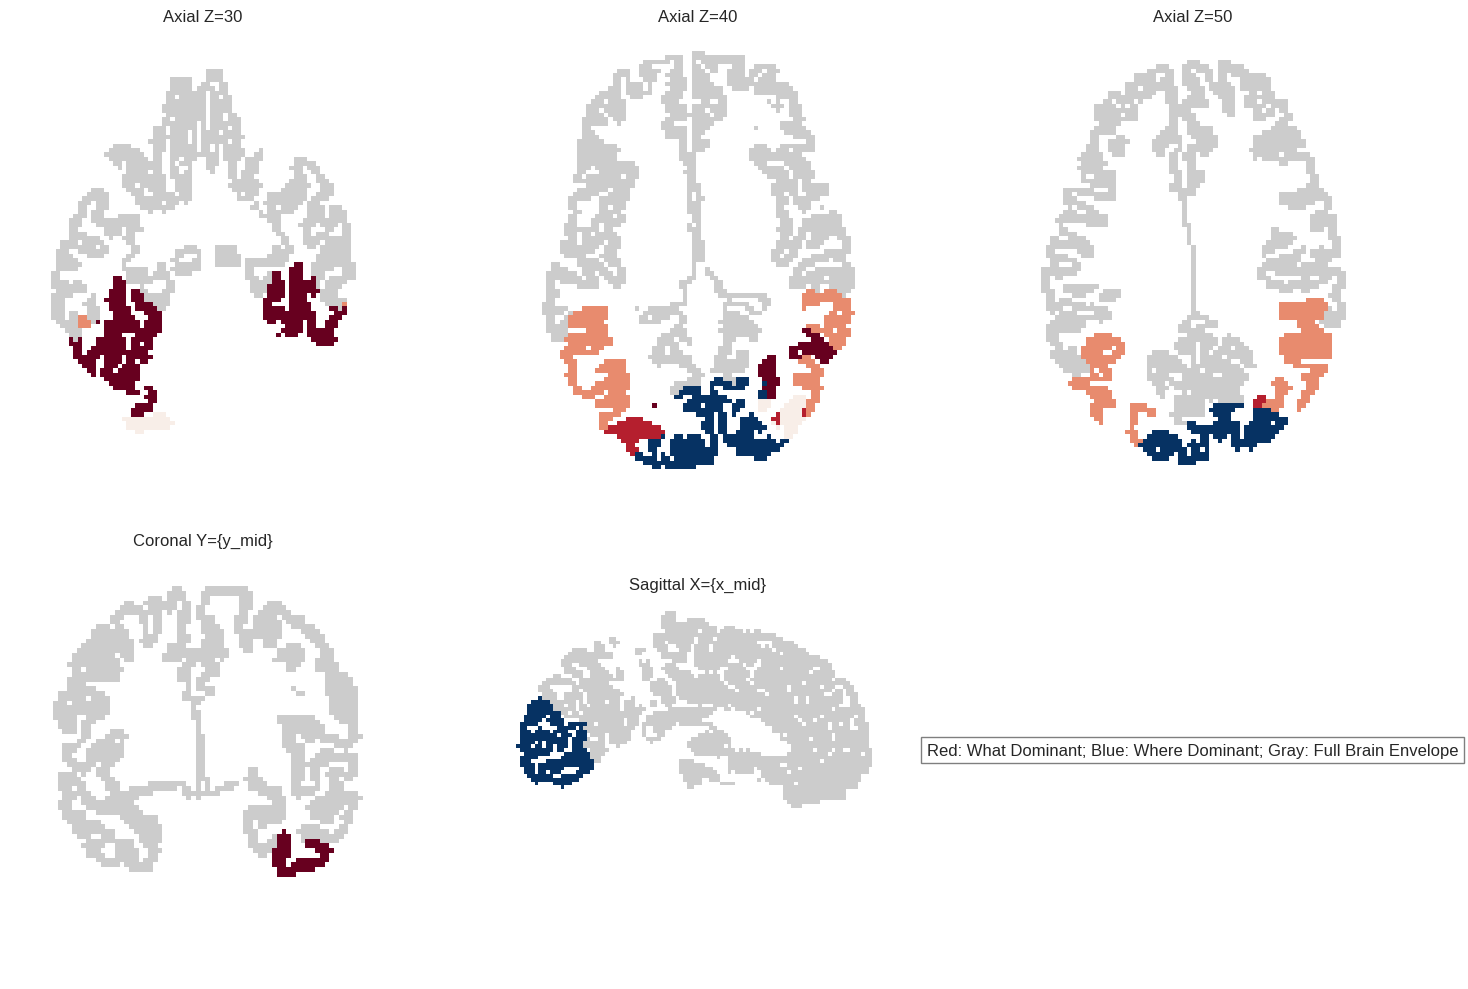

In [18]:
# ===== BRAIN VISUALIZATION (ENHANCED FIT) =====
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor="white")

# Create a full brain mask from streams_data to show the background shape
brain_mask = (streams_data != 0).astype(float)

vmax = max(abs(corr_diff_volume.min()), abs(corr_diff_volume.max()))
if vmax < 0.01: vmax = 0.1

z_slices = [30, 40, 50]
for i, z in enumerate(z_slices):
    ax = axes[0, i]
    # Draw background brain in light gray
    bg_data = brain_mask[:, :, z]
    ax.imshow(bg_data.T, cmap="gray", alpha=0.2, origin="lower", aspect="equal")
    # Overlay fMRI data
    slice_data = corr_diff_volume[:, :, z]
    # Mask zero values for better overlay
    masked_data = np.ma.masked_where(slice_data == 0, slice_data)
    im = ax.imshow(masked_data.T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower", aspect="equal")
    ax.set_title(f"Axial Z={z}")
    ax.axis("off")

# Coronal View
ax = axes[1, 0]
y_mid = 60 # Focusing on back of the brain
ax.imshow(brain_mask[:, y_mid, :].T, cmap="gray", alpha=0.2, origin="lower", aspect="equal")
slice_data = np.ma.masked_where(corr_diff_volume[:, y_mid, :] == 0, corr_diff_volume[:, y_mid, :])
ax.imshow(slice_data.T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower", aspect="equal")
ax.set_title("Coronal Y={y_mid}")
ax.axis("off")

# Sagittal View
ax = axes[1, 1]
x_mid = 40
ax.imshow(brain_mask[x_mid, :, :].T, cmap="gray", alpha=0.2, origin="lower", aspect="equal")
slice_data = np.ma.masked_where(corr_diff_volume[x_mid, :, :] == 0, corr_diff_volume[x_mid, :, :])
ax.imshow(slice_data.T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower", aspect="equal")
ax.set_title("Sagittal X={x_mid}")
ax.axis("off")

# Legend/Info
ax = axes[1, 2]
ax.axis("off")
ax.text(0.5, 0.5, "Red: What Dominant; Blue: Where Dominant; Gray: Full Brain Envelope", 
        ha="center", va="center", fontsize=12, transform=ax.transAxes, 
        bbox=dict(facecolor="white", alpha=0.5))

plt.tight_layout()
plt.show()

/tmp/ipykernel_192006/174670649.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


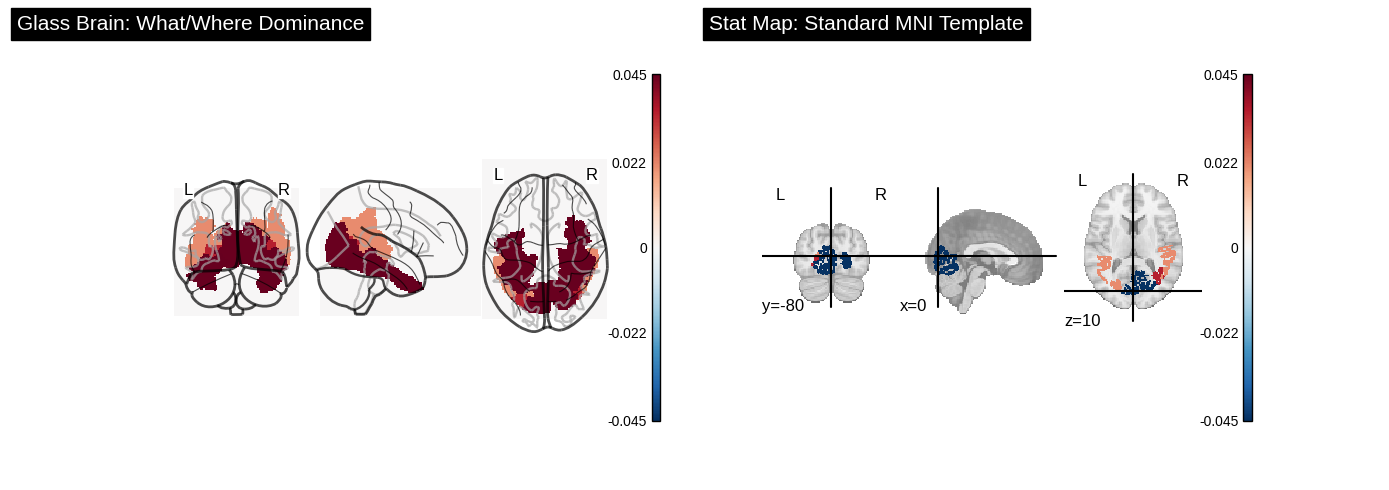

In [19]:
# ===== NILEARN GLASS BRAIN & STAT MAP =====
from nilearn import plotting

# Glass brain view (3D transparent brain)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Glass brain
ax1 = axes[0]
plotting.plot_glass_brain(corr_diff_nii, 
                          colorbar=True,
                          cmap='RdBu_r',
                          symmetric_cbar=True,
                          title='Glass Brain: What/Where Dominance',
                          axes=ax1)

# Plot 2: Stat map on anatomical (if available)
ax2 = axes[1]
plotting.plot_stat_map(corr_diff_nii,
                       
                       cmap='RdBu_r',
                       symmetric_cbar=True,
                       title='Stat Map: Standard MNI Template',
                       axes=ax2,
                       display_mode='ortho',
                       cut_coords=(0, -80, 10))  # Focus on visual cortex

plt.tight_layout()
plt.savefig('../docs/what_where_glass_brain.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1600x1200 with 0 Axes>

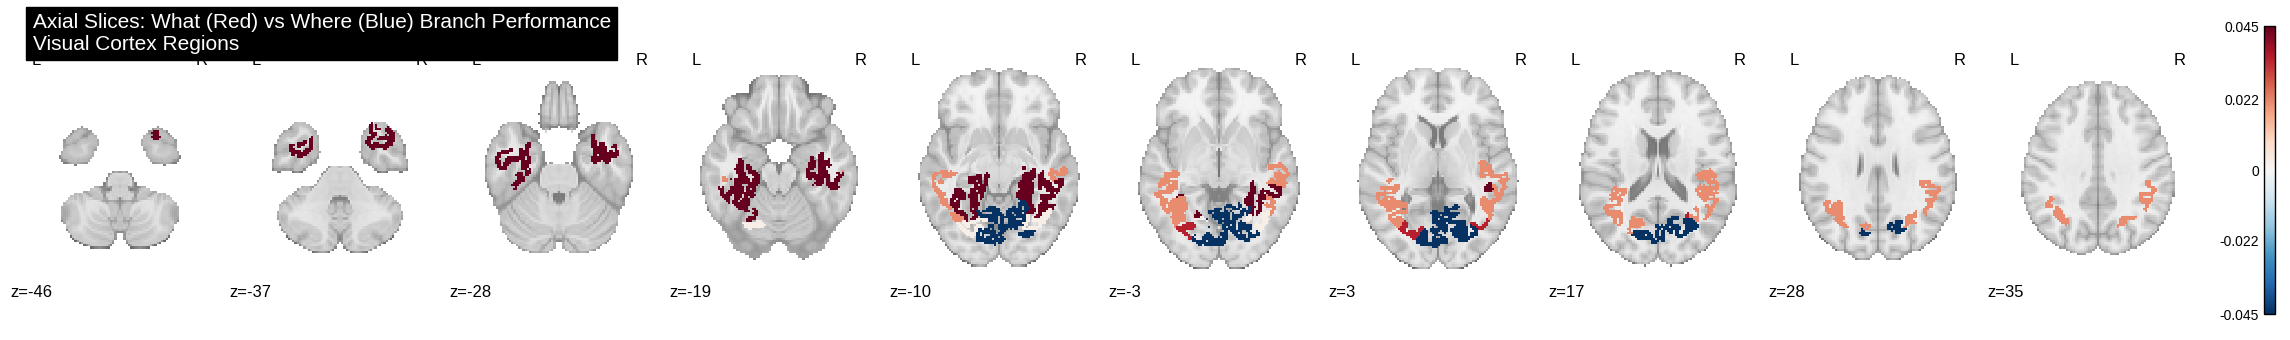

<Figure size 1600x600 with 0 Axes>

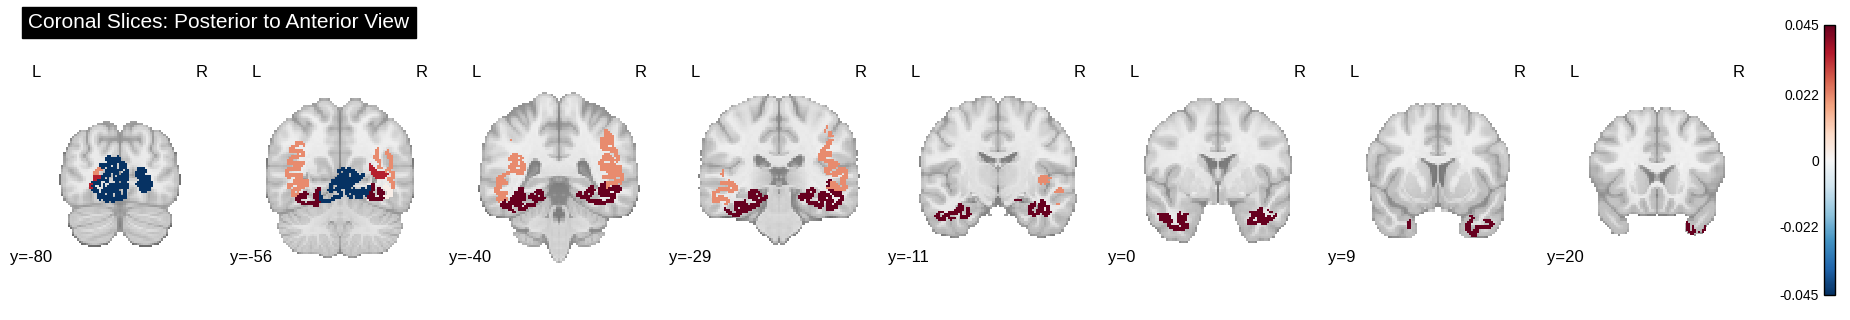

In [20]:
# ===== MULTIPLE SLICES VIEW =====
# Show multiple axial slices through visual cortex

fig = plt.figure(figsize=(16, 12))

# Use nilearn's plot_stat_map with mosaic display
display = plotting.plot_stat_map(
    corr_diff_nii,
    cmap='RdBu_r',
    symmetric_cbar=True,
    display_mode='z',  # Axial slices
    cut_coords=10,      # Number of slices
    title='Axial Slices: What (Red) vs Where (Blue) Branch Performance\n'
          'Visual Cortex Regions'
)

plt.savefig('../docs/what_where_axial_slices.png', dpi=100, bbox_inches='tight')
plt.show()

# Also show coronal view (good for visual cortex)
fig = plt.figure(figsize=(16, 6))
display = plotting.plot_stat_map(
    corr_diff_nii,
    cmap='RdBu_r', 
    symmetric_cbar=True,
    display_mode='y',  # Coronal slices
    cut_coords=8,
    title='Coronal Slices: Posterior to Anterior View'
)
plt.savefig('../docs/what_where_coronal_slices.png', dpi=100, bbox_inches='tight')
plt.show()